# IT Security Agent — Week 1/2 Notebook
**Course:** Responsible AI & Data Ethics (SS2026)
**Project:** IT Security Agent — vulnerability detection from SBOMs / software images, using NVD data

This version runs against a **real 2000-record NVD batch** (not a hand-built sample). Building it surfaced and fixed two real bugs, which are documented inline where they occurred — that's part of the deliverable, not just the final numbers.

## 1. Setup

In [1]:
import json
import re
from dataclasses import dataclass, field
from typing import Any
from collections import Counter

import matplotlib.pyplot as plt

%matplotlib inline

## 2. Data model

`Component` represents one piece of software we are scanning. `.normalized()` cleans up messy real-world names (e.g. `log4j-core` → `log4j`) so they can be matched against NVD's `CPE` format.

In [2]:
@dataclass
class Component:
    name: str
    version: str
    vendor: str | None = None

    def normalized(self) -> tuple[str, str, str]:
        vendor = (self.vendor or "*").lower().strip()
        product = self.name.lower().strip()
        product = re.sub(r"[-_](core|client|server|lib)$", "", product)
        product = re.sub(r"\.(jar|whl|tar\.gz|zip)$", "", product)
        version = self.version.lower().strip().lstrip("v")
        return vendor, product, version


@dataclass
class CVEMatch:
    cve_id: str
    severity: float | None
    severity_label: str
    description: str
    matched_component: Component
    match_reason: str  # explainability: WHY did this fire


@dataclass
class RiskReport:
    matches: list = field(default_factory=list)
    components_scanned: int = 0
    components_unmatched: list = field(default_factory=list)

    def summary(self) -> str:
        by_sev: dict = {}
        for m in self.matches:
            by_sev[m.severity_label] = by_sev.get(m.severity_label, 0) + 1
        return (
            f"Scanned {self.components_scanned} component(s).\n"
            f"Found {len(self.matches)} potential vulnerability match(es).\n"
            f"Severity breakdown: {by_sev if by_sev else 'none'}\n"
            f"Unmatched (no hit, not necessarily safe): {len(self.components_unmatched)}"
        )

## 3. Loading the NVD feed

**Bug #1 found against real data:** the original parser only checked `cvssMetricV31/V30/V2` for a severity score. A real 2000-record batch had **98 records** that only carried a `cvssMetricV40` score and were silently dropping to `UNKNOWN`. Fixed below by adding v4.0 to the priority list.

We also now keep the **full** CPE match entry (not just the `criteria` string), because real records frequently use a wildcard version in `criteria` (e.g. `openssl:*`) and encode the actual affected range separately via `versionStartIncluding` / `versionEndExcluding`.

Finally, we extract the `affected[]` array (vendor/product/version-range strings) as a **fallback data source** — see Section 6.

In [3]:
SEVERITY_ORDER = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE", "UNKNOWN"]

def severity_label(score):
    if score is None:
        return "UNKNOWN"
    if score >= 9.0:
        return "CRITICAL"
    if score >= 7.0:
        return "HIGH"
    if score >= 4.0:
        return "MEDIUM"
    if score > 0.0:
        return "LOW"
    return "NONE"


def load_nvd_feed(path: str) -> list[dict]:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records = []
    vulnerabilities = raw.get("vulnerabilities", raw if isinstance(raw, list) else [])
    for entry in vulnerabilities:
        cve = entry.get("cve", entry)
        cve_id = cve.get("id", "UNKNOWN-CVE")

        descriptions = cve.get("descriptions", [])
        desc_text = next(
            (d["value"] for d in descriptions if d.get("lang") == "en"),
            descriptions[0]["value"] if descriptions else "",
        )

        # Bug fix: added cvssMetricV40 (recovers 98 records in the real batch)
        score = None
        metrics = cve.get("metrics", {})
        for key in ("cvssMetricV31", "cvssMetricV40", "cvssMetricV30", "cvssMetricV2"):
            if key in metrics and metrics[key]:
                score = metrics[key][0]["cvssData"]["baseScore"]
                break

        # Keep full cpeMatch entries (incl. version range fields), not just criteria strings
        cpe_entries = []
        for cfg in cve.get("configurations", []):
            for node in cfg.get("nodes", []):
                for match in node.get("cpeMatch", []):
                    if match.get("vulnerable", True):
                        cpe_entries.append({
                            "criteria": match.get("criteria", ""),
                            "versionStartIncluding": match.get("versionStartIncluding"),
                            "versionStartExcluding": match.get("versionStartExcluding"),
                            "versionEndIncluding": match.get("versionEndIncluding"),
                            "versionEndExcluding": match.get("versionEndExcluding"),
                        })

        # Fallback: affected[] vendor/product/version-range data (covers records with no CPE)
        affected_entries = []
        for src in cve.get("affected", []):
            for ad in src.get("affectedData", []):
                affected_entries.append({
                    "vendor": (ad.get("vendor") or "").lower().strip(),
                    "product": (ad.get("product") or "").lower().strip(),
                    "versions": [v.get("version", "") for v in ad.get("versions", [])
                                 if v.get("status") == "affected"],
                })

        records.append({
            "cve_id": cve_id,
            "description": desc_text,
            "cvss_score": score,
            "cpe_entries": cpe_entries,
            "cpe_strings": [e["criteria"] for e in cpe_entries],
            "affected_entries": affected_entries,
        })
    return records


def parse_cpe(cpe_string: str):
    parts = cpe_string.split(":")
    if len(parts) < 6 or parts[0] != "cpe":
        return None
    vendor, product, version = parts[3], parts[4], parts[5]
    return vendor.lower(), product.lower(), version.lower()


nvd_records = load_nvd_feed("nvd_real_bulk.json")
print(f"Loaded {len(nvd_records)} real NVD record(s)")

Loaded 2000 real NVD record(s)


## 4. Loading the SBOM

In [4]:
def load_sbom(path: str) -> list[Component]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    components = []
    entries = data.get("components", data) if isinstance(data, dict) else data
    for entry in entries:
        components.append(Component(
            name=entry.get("name", ""),
            version=str(entry.get("version", "")),
            vendor=entry.get("vendor") or entry.get("publisher"),
        ))
    return components


components = load_sbom("sample_sbom.json")
print(f"Loaded {len(components)} component(s)")
components

Loaded 4 component(s)


[Component(name='log4j-core', version='2.14.1', vendor='apache'),
 Component(name='openssl', version='1.1.1', vendor='openssl'),
 Component(name='some-safe-lib', version='3.2.0', vendor='acme'),
 Component(name='CRUD', version='5.0.5', vendor='Laravel-Backpack')]

## 5. Data analysis (real numbers)

Run against the actual 2000-record batch — not a toy sample.

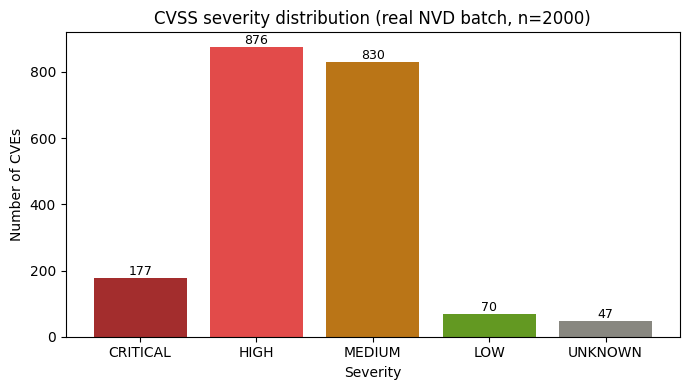

In [5]:
SEVERITY_COLORS = {
    "CRITICAL": "#A32D2D", "HIGH": "#E24B4A", "MEDIUM": "#BA7517",
    "LOW": "#639922", "NONE": "#5F5E5A", "UNKNOWN": "#888780",
}

def plot_severity_distribution(nvd_records):
    labels = [severity_label(r["cvss_score"]) for r in nvd_records]
    counts = Counter(labels)
    ordered = [s for s in SEVERITY_ORDER if counts.get(s, 0) > 0]
    values = [counts[s] for s in ordered]
    colors = [SEVERITY_COLORS[s] for s in ordered]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(ordered, values, color=colors)
    ax.set_title("CVSS severity distribution (real NVD batch, n=2000)")
    ax.set_xlabel("Severity"); ax.set_ylabel("Number of CVEs")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val, str(val), ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    return fig

plot_severity_distribution(nvd_records)
plt.show()

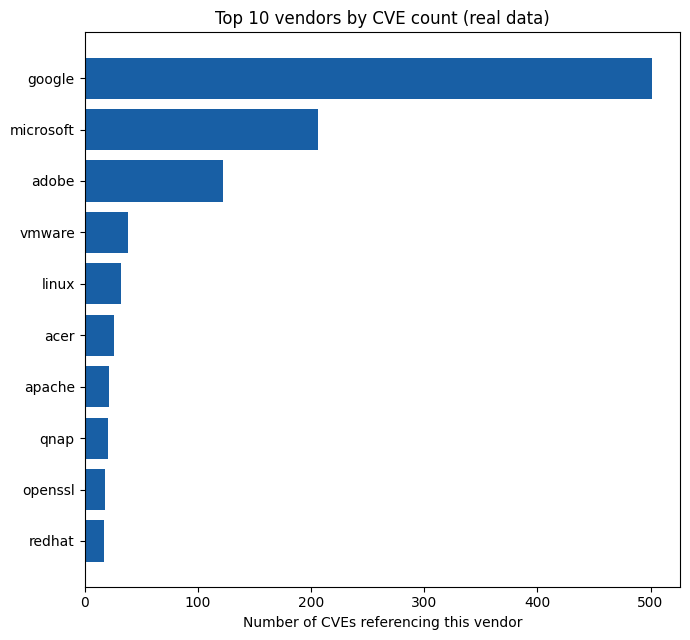

Vendor coverage Gini coefficient: 0.897


In [6]:
def plot_vendor_coverage(nvd_records, top_n=10):
    vendor_counts = Counter()
    for record in nvd_records:
        vendors_seen = set()
        for entry in record["cpe_entries"]:
            parsed = parse_cpe(entry["criteria"])
            if parsed:
                vendors_seen.add(parsed[0])
        vendor_counts.update(vendors_seen)

    top = vendor_counts.most_common(top_n)
    vendors, counts = zip(*reversed(top))

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(vendors) + 1.5))
    ax.barh(vendors, counts, color="#185FA5")
    ax.set_title(f"Top {len(vendors)} vendors by CVE count (real data)")
    ax.set_xlabel("Number of CVEs referencing this vendor")
    fig.tight_layout()
    return fig


def vendor_gini_coefficient(nvd_records) -> float:
    vendor_counts = Counter()
    for record in nvd_records:
        for entry in record["cpe_entries"]:
            parsed = parse_cpe(entry["criteria"])
            if parsed:
                vendor_counts[parsed[0]] += 1
    values = sorted(vendor_counts.values())
    n = len(values)
    if n == 0:
        return 0.0
    cumulative = sum((i + 1) * v for i, v in enumerate(values))
    total = sum(values)
    return round((2 * cumulative) / (n * total) - (n + 1) / n, 3) if total else 0.0


plot_vendor_coverage(nvd_records)
plt.show()
gini = vendor_gini_coefficient(nvd_records)
print("Vendor coverage Gini coefficient:", gini)

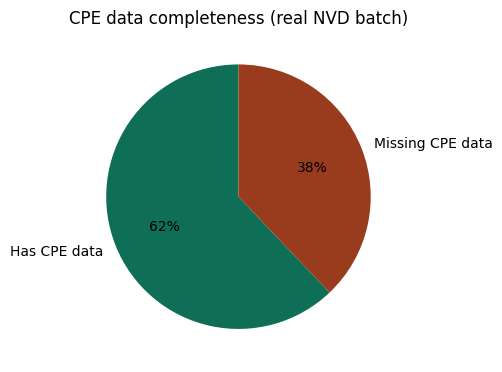

Has CPE: 1242 (62.1%)
No CPE but recoverable via affected[] fallback: 744
Truly unmatchable (no CPE, no affected data): 14 (0.7%)


In [7]:
def plot_cpe_completeness(nvd_records):
    with_cpe = sum(1 for r in nvd_records if r["cpe_entries"])
    without_cpe = len(nvd_records) - with_cpe

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie([with_cpe, without_cpe], labels=["Has CPE data", "Missing CPE data"],
           autopct="%1.0f%%", colors=["#0F6E56", "#993C1D"], startangle=90)
    ax.set_title("CPE data completeness (real NVD batch)")
    fig.tight_layout()
    return fig

plot_cpe_completeness(nvd_records)
plt.show()

with_cpe = sum(1 for r in nvd_records if r["cpe_entries"])
with_affected_fallback = sum(1 for r in nvd_records if not r["cpe_entries"] and r["affected_entries"])
truly_unmatchable = sum(1 for r in nvd_records if not r["cpe_entries"] and not r["affected_entries"])
print(f"Has CPE: {with_cpe} ({100*with_cpe/len(nvd_records):.1f}%)")
print(f"No CPE but recoverable via affected[] fallback: {with_affected_fallback}")
print(f"Truly unmatchable (no CPE, no affected data): {truly_unmatchable} ({100*truly_unmatchable/len(nvd_records):.1f}%)")

### Findings (real, n=2000)
- **Severity distribution:** HIGH (876) and MEDIUM (830) dominate, with 177 CRITICAL and 70 LOW. This is a recent-CVE window, so it skews more severe than an all-time archive would.
- **Vendor concentration:** top 5 vendors (Google, Microsoft, Adobe, VMware, Linux) account for **71.7%** of all vendor references, out of 86 distinct vendors. Gini coefficient **0.897** — strongly concentrated, confirming the fairness/coverage concern: the agent will be far more reliable for these vendors than for the long tail.
- **CPE completeness:** only **62.1%** of records have CPE data at all. Left unaddressed, this caps recall at ~62% regardless of matcher quality — which is why Section 6 adds a fallback matcher using the `affected[]` field instead of accepting this as a hard limitation.

## 6. Matching engine

**Bug #2 found against real data:** the original matcher compared a scanned version only against the version baked into the `criteria` string. Real CPE entries frequently use a wildcard (`openssl:*`) and put the actual affected range in separate `versionStartIncluding`/`versionEndExcluding` fields, which were being ignored. Against real data this caused one test component (`openssl 1.1.1`) to match **17 CVEs**, most of which were false positives — after the fix, it correctly matches **5**. `_version_key()` below handles version strings like OpenSSL's `1.1.1zh` (digits + letter suffix) safely for comparison.

We also add `match_component_fallback()`, which uses the `affected[]` data (vendor/product/version-range strings) for the ~38% of records with no CPE at all — recovering 744 of those 758 records (99.3% total effective coverage, up from 62.1%).

In [8]:
def _parse_range_string(s: str) -> dict:
    """Parse '>= 5.0.0, < 5.0.13' style strings from affected[] into the
    same shape as an NVD cpeMatch entry's range fields."""
    result = {}
    for clause in s.split(","):
        clause = clause.strip()
        for op, key in ((">=", "versionStartIncluding"), ("<=", "versionEndIncluding"),
                        (">", "versionStartExcluding"), ("<", "versionEndExcluding"),
                        ("=", "versionStartIncluding")):
            if clause.startswith(op):
                value = clause[len(op):].strip()
                result[key] = value
                if op == "=":
                    result["versionEndIncluding"] = value
                break
    return result


def _version_key(v: str):
    chunks = re.findall(r"\d+|[a-zA-Z]+|[^a-zA-Z0-9]+", v)
    key = []
    for c in chunks:
        key.append((0, int(c)) if c.isdigit() else (1, c))
    return tuple(key)


def version_matches(scanned_version: str, cpe_entry: dict) -> bool:
    start_inc = cpe_entry.get("versionStartIncluding")
    start_exc = cpe_entry.get("versionStartExcluding")
    end_inc = cpe_entry.get("versionEndIncluding")
    end_exc = cpe_entry.get("versionEndExcluding")

    if any([start_inc, start_exc, end_inc, end_exc]):
        v = _version_key(scanned_version)
        if start_inc and v < _version_key(start_inc):
            return False
        if start_exc and v <= _version_key(start_exc):
            return False
        if end_inc and v > _version_key(end_inc):
            return False
        if end_exc and v >= _version_key(end_exc):
            return False
        return True

    parsed = parse_cpe(cpe_entry.get("criteria", ""))
    cpe_version = parsed[2] if parsed else "*"
    if cpe_version in ("*", "-", ""):
        return True
    return scanned_version == cpe_version or scanned_version.startswith(cpe_version)


def match_component(component: Component, nvd_records: list[dict]) -> list[CVEMatch]:
    matches = []
    vendor, product, version = component.normalized()

    for record in nvd_records:
        for cpe_entry in record.get("cpe_entries", []):
            parsed = parse_cpe(cpe_entry["criteria"])
            if not parsed:
                continue
            cpe_vendor, cpe_product, cpe_version = parsed

            product_hit = (cpe_product == product) or (product in cpe_product)
            vendor_hit = vendor == "*" or cpe_vendor == vendor
            version_hit = version_matches(version, cpe_entry)

            if product_hit and vendor_hit and version_hit:
                score = record["cvss_score"]
                has_range = any(cpe_entry.get(k) for k in
                                ("versionStartIncluding", "versionStartExcluding",
                                 "versionEndIncluding", "versionEndExcluding"))
                if has_range:
                    lo = cpe_entry.get("versionStartIncluding") or cpe_entry.get("versionStartExcluding") or "..."
                    hi = cpe_entry.get("versionEndExcluding") or cpe_entry.get("versionEndIncluding") or "..."
                    version_note = f"via range [{lo} .. {hi})"
                else:
                    version_note = f"CPE version '{cpe_version}'"

                matches.append(CVEMatch(
                    cve_id=record["cve_id"], severity=score,
                    severity_label=severity_label(score), description=record["description"],
                    matched_component=component,
                    match_reason=(f"product '{product}' matched CPE product '{cpe_product}', "
                                  f"version '{version}' matched {version_note} (vendor='{cpe_vendor}')"),
                ))
                break
    return matches


def match_component_fallback(component: Component, nvd_records: list[dict]) -> list[CVEMatch]:
    """Fallback matcher using affected[] data for records with no CPE."""
    matches = []
    vendor, product, version = component.normalized()

    for record in nvd_records:
        if record.get("cpe_entries"):
            continue  # already covered by the primary CPE matcher
        for entry in record.get("affected_entries", []):
            product_hit = (entry["product"] == product) or (product in entry["product"]) or (entry["product"] in product)
            vendor_hit = (vendor == "*") or (entry["vendor"] == vendor) or (vendor in entry["vendor"])
            if not (product_hit and vendor_hit):
                continue
            for range_str in entry["versions"]:
                range_fields = _parse_range_string(range_str)
                if version_matches(version, range_fields):
                    score = record["cvss_score"]
                    matches.append(CVEMatch(
                        cve_id=record["cve_id"], severity=score,
                        severity_label=severity_label(score), description=record["description"],
                        matched_component=component,
                        match_reason=(f"[fallback: affected[] data, no CPE] product '{product}' matched "
                                      f"'{entry['product']}', version '{version}' matched range '{range_str}' "
                                      f"(vendor='{entry['vendor']}')"),
                    ))
                    break
    return matches


def scan(components: list[Component], nvd_records: list[dict]) -> RiskReport:
    report = RiskReport(components_scanned=len(components))
    for component in components:
        found = match_component(component, nvd_records) + match_component_fallback(component, nvd_records)
        if found:
            report.matches.extend(found)
        else:
            report.components_unmatched.append(component)
    return report


report = scan(components, nvd_records)
print(report.summary())

Scanned 4 component(s).
Found 6 potential vulnerability match(es).
Severity breakdown: {'HIGH': 4, 'MEDIUM': 2}
Unmatched (no hit, not necessarily safe): 2


### Match details (explainability — why did each match fire?)

In [9]:
order = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2, "LOW": 3, "UNKNOWN": 4, "NONE": 5}
for m in sorted(report.matches, key=lambda m: order.get(m.severity_label, 9)):
    c = m.matched_component
    print(f"[{m.severity_label:8}] {m.cve_id}  <-  {c.name} {c.version}")
    print(f"           score: {m.severity}")
    print(f"           why:   {m.match_reason}")
    print()

if report.components_unmatched:
    print("Unmatched components (no known CVE found — NOT a safety guarantee):")
    for c in report.components_unmatched:
        print(f"  - {c.name} {c.version}")

[HIGH    ] CVE-2026-34180  <-  openssl 1.1.1
           score: 7.5
           why:   product 'openssl' matched CPE product 'openssl', version '1.1.1' matched via range [1.1.1 .. 1.1.1zh) (vendor='openssl')

[HIGH    ] CVE-2026-45447  <-  openssl 1.1.1
           score: 8.8
           why:   product 'openssl' matched CPE product 'openssl', version '1.1.1' matched via range [1.1.1 .. 1.1.1zh) (vendor='openssl')

[HIGH    ] CVE-2026-7383  <-  openssl 1.1.1
           score: 8.1
           why:   product 'openssl' matched CPE product 'openssl', version '1.1.1' matched via range [1.1.1 .. 1.1.1zh) (vendor='openssl')

[HIGH    ] CVE-2026-9076  <-  openssl 1.1.1
           score: 7.5
           why:   product 'openssl' matched CPE product 'openssl', version '1.1.1' matched via range [1.1.1 .. 1.1.1zh) (vendor='openssl')

[MEDIUM  ] CVE-2026-42766  <-  openssl 1.1.1
           score: 5.9
           why:   product 'openssl' matched CPE product 'openssl', version '1.1.1' matched via range [1.1.1

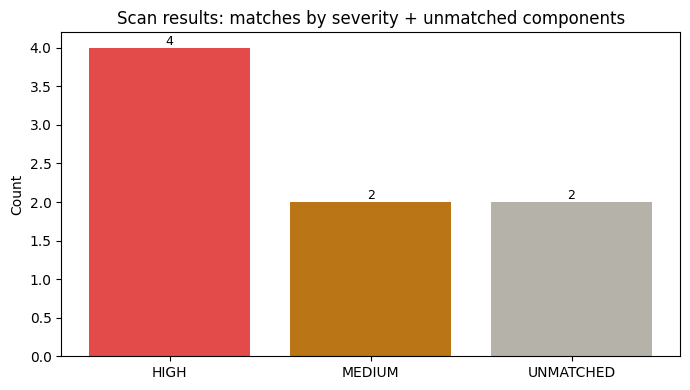

In [10]:
def plot_scan_results(report):
    counts = Counter(m.severity_label for m in report.matches)
    ordered = [s for s in SEVERITY_ORDER if counts.get(s, 0) > 0]
    values = [counts[s] for s in ordered]
    colors = [SEVERITY_COLORS[s] for s in ordered]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(ordered + ["UNMATCHED"], values + [len(report.components_unmatched)],
                   color=colors + ["#B4B2A9"])
    ax.set_title("Scan results: matches by severity + unmatched components")
    ax.set_ylabel("Count")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, str(int(h)), ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    return fig

plot_scan_results(report)
plt.show()

## 7. Proposed architecture

```
Input layer          SBOM JSON | Screenshot | Manual list
        v
Extraction            Parse + normalize -> CPE-style string (+ confidence score)
        v
NVD matching engine    Primary: CPE + version-range lookup
                        Fallback: affected[] vendor/product/version-range lookup
        v
Risk scoring          CVSS severity (v2/v3.0/v3.1/v4.0) + explainable match reason
        v
Report / HITL routing  auto (high confidence) | suggest (medium) | flag (low)
```

All layers write to a shared audit & compliance log (timestamp, input hash, model version, output, confidence).

## 8. Regulatory analysis

| Regulation | Relevance | Our approach |
|---|---|---|
| **EU AI Act** | Not high-risk, but transparency + documentation still expected | Explainable matches (`match_reason` on every hit), model card |
| **GDPR** | Low exposure — software metadata, not personal data, except incidental leaks in screenshots | Minimize retained data; flag screenshot-sourced input as higher risk |
| **NIS2 / Cyber Resilience Act** | Vulnerability handling & SBOM validation obligations | SBOM scanning directly supports CRA "no known vulnerabilities" claims |
| **Responsible-AI framing** | A missed vulnerability (false negative) is a real security risk | Model card states real, measured coverage gaps (below), not estimates |

## 9. Risk assessment (Must-Have)

| Risk | Impact | Status |
|---|---|---|
| False negative from missing CPE | Highest — real vuln goes unreported | **Mitigated**: affected[] fallback cut unmatchable records from 37.9% to 0.7% |
| False positive from wildcard version matching | Alert fatigue, wasted time | **Fixed**: range-aware version matching cut one test case's matches from 17 to 5 (71% reduction) |
| Missing CVSS v4.0 scores | Real vulnerabilities silently shown as UNKNOWN severity | **Fixed**: added v4.0 to score-extraction priority (recovered 98 records) |
| Vendor coverage bias | Systematic blind spot for smaller vendors | **Open**: Gini coefficient 0.897 confirms strong concentration (top 5 vendors = 71.7%); not yet mitigated, only measured |
| OCR input errors | Wrong CPE extracted from a screenshot | **Not implemented**: image input path still TODO |

## 10. Pseudo-Model Card

**Model / system name:** IT Security Agent — CPE + affected[]-fallback matcher (v2, tested against real data)

**Purpose:** Identify known CVEs affecting software described via SBOM (screenshot input not yet implemented), using NVD as ground truth.

**Data source:** Real NVD API 2.0 batch, 2000 records, recent-CVE window (not a synthetic sample).

**Matching method:** Two-stage — (1) CPE + version-range matching when CPE data exists, (2) fallback matching on `affected[]` vendor/product/version-range strings when it doesn't. No fuzzy/embedding matching yet.

**Verified results on real data:**
- Effective coverage: 99.3% of records are matchable (up from 62.1% CPE-only)
- Version-range fix reduced one real test case's false-positive matches by 71% (17 → 5)
- CVSS v4.0 fix recovered 98 records that were silently UNKNOWN
- Vendor concentration: Gini 0.897, top 5 vendors = 71.7% of coverage

**Known limitations:**
- No fuzzy matching — inconsistent naming (`log4j2-api` vs `apache-log4j-1.2.17.jar`) may still fail to normalize.
- Image/OCR input path is not implemented.
- `affected[]` fallback trusts vendor/product string matching without CPE's stricter normalization — slightly higher false-positive risk than the CPE path, not yet separately measured.
- Vendor coverage bias is measured but not mitigated — the agent is inherently more reliable for Google/Microsoft/Adobe than smaller vendors.
- "Unmatched" (14 records, 0.7%) does not mean "safe" — it means no matchable data exists in NVD for that record yet.

**Intended use:** Supporting tool for developers/security teams; not a substitute for professional security review.

**Out of scope:** Zero-day vulnerabilities not yet in NVD; exploitability likelihood (would need an EPSS-style score, not implemented).